# Post-Treatement of the data
The aim of this notebook is to import the different simulations, and compute the different indices of quality as well as the volume.  
The indices we calculate are the following for the synthetic :
1. Sum of the error 
2. Absolute sum of the error
3. Normalized Sum
4. Standard Deviation
5. Mean

For the real data, we just compute the volume.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
import os
import time
from matplotlib.backends.backend_pdf import PdfPages

Define the path of the data

In [86]:
path_output_krig = '../simulation_output_krig_set1/'
path_output_MPS  = '../simulation_output_set_2/'

simulation_name_krig = os.listdir(path_output_krig)
simulation_name = os.listdir(path_output_MPS)
simulation_name_krig = sorted(simulation_name_krig)
simulation_name = sorted(simulation_name)

exec(open('../functions/03_indice_calculation_functions.py').read())


In [87]:
simulation_name[0:3], simulation_name_krig[0:3]

(['realisation0_simu.pickle',
  'realisation1_simu.pickle',
  'realisation2_simu.pickle'],
 ['realisation0_krige.pickle',
  'realisation1_krige.pickle',
  'realisation2_krige.pickle'])

In [88]:
with open(path_output_MPS+simulation_name[4],'rb') as file:
    simus_sets = pickle.load(file)

trueMNT,[extr2,None,simGRF],mask[1], ref

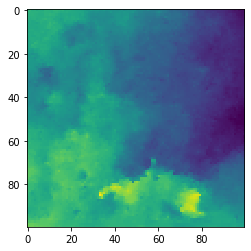

In [89]:
plt.imshow(simus_sets[1][0][0])

In [90]:
simus_sets[3]

array([2644, 2744,  791,  891])

In [91]:
a =[0,9]

In [92]:
np.all(a != None)

True

## Simulation output

In [93]:
all_output = []
real_vol = []
type_sim = ['MPS','GRF']
for name in simulation_name:
    
    with open(path_output_MPS+name,'rb') as file:
        trueMNT, simu_sets, mask_box_ti, position = pickle.load(file)

    for i, simus in enumerate(simu_sets):        
        if np.all(simus != None):
            indice_out = indice_calculationA(trueMNT, simus, 'mps')
        
            all_output.append([name[:-12], type_sim[i]]+indice_out)
        
        
results_frame_2 = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume','Real Volume'])



/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:83: RuntimeWarning: divide by zero encountered in true_divide
/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:83: RuntimeWarning: invalid value encountered in true_divide


## Kriging output

In [94]:
all_output = []
real_vol = []
type_sim = ['KRIG']
for name in simulation_name_krig:
    
    with open(path_output_krig+name,'rb') as file:
        trueMNT, simu_sets, mask_box_ti, position = pickle.load(file)

    if np.all(simu_sets != None):
        indice_out = indice_calculationV(trueMNT, simu_sets, 'krig')
        
        all_output.append([name[:-12], type_sim[0]] +indice_out)
        
        
results_frame_k = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume','Real Volume'])



/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:129: RuntimeWarning: invalid value encountered in true_divide


In [95]:
%xmode plain

Exception reporting mode: Plain


In [96]:
results_frame.head()

,Sim_name,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,Real Volume
0,realisation0,MPS,-1.077908,3.953157,1.529213,"[[2291.331095377604, 2292.1310831705728, 2292....","[[1.2695712463078292, 0.9552561663994423, 1.03...","[508275.34985351446, 501459.7912597647, 507108...",500000.0
1,realisation0,GRF,1.177412,2.197011,2.084065,"[[2291.49560546875, 2291.9052734375, 2292.2998...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[484563.2774932699, 491163.50508440856, 491776...",500000.0
2,realisation1,MPS,-0.738012,4.220706,1.362898,"[[2523.9186808268228, 2523.8616739908853, 2523...","[[1.1217204764903208, 1.5361589144055094, 1.49...","[515361.11938476475, 507816.22839355393, 50777...",500000.0
3,realisation1,GRF,1.115147,2.278073,2.168823,"[[2524.07373046875, 2524.07373046875, 2524.130...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[490996.05394690257, 488725.86456809484, 48833...",500000.0
4,realisation2,MPS,-1.306877,3.851336,1.956431,"[[2150.504842122396, 2151.3503621419272, 2151....","[[0.6046460773542204, 1.3034692412447249, 1.13...","[510183.81262206944, 518592.18432617135, 51135...",500000.0


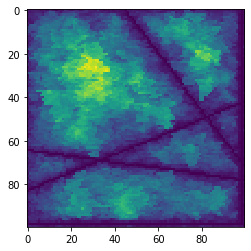

In [97]:
plt.imshow(results_frame.Sd[0])

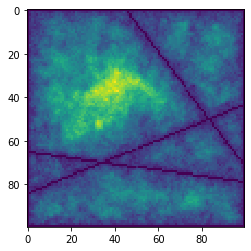

In [98]:
plt.imshow(results_frame.Sd[1])

In [15]:
dirName ='simu_reports'
numbers = []
try:
    # Create target Directory
    os.mkdir(dirName)
    print("Directory " , dirName ,  " Created ") 
    pdf_name = 'pdf_report_001.pdf'
except FileExistsError:
    print("Directory " , dirName ,  " already exists")
    pdf_name = os.listdir(dirName)
    for pdf_me in pdf_name:
        numbers.append(pdf_me[11:12])
    pdf_name = 'pdf_report_'+ str(int(max(numbers))+1).rjust(3, '0')+'.pdf' 


Directory  simu_reports  already exists


In [16]:
pdf_name

'pdf_report_010.pdf'

Text(0, 0.5, 'Error [m]')

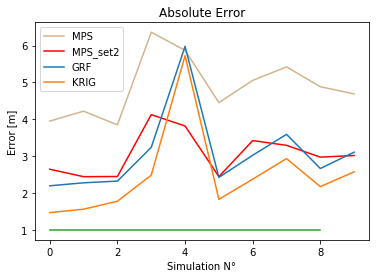

In [108]:
plt.plot(results_frame[results_frame['Type']=='MPS'].Abs_error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Abs_error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Abs_error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Abs_error.values)
plt.plot(np.arange(0,9,1),[1]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')


Text(0, 0.5, 'Error [m]')

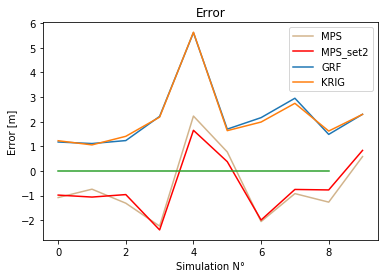

In [107]:
plt.plot(results_frame[results_frame['Type']=='MPS'].Error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Error.values)
plt.plot(np.arange(0,9,1),[0]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')

#plt.plot(np.ones(len(pts_0))*0,color='grey',ls='--')

Text(0, 0.5, 'Error [m]')

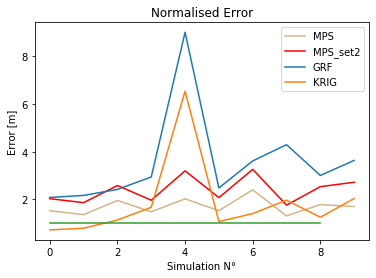

In [106]:
#etrange!!!!!!
plt.plot(results_frame[results_frame['Type']=='MPS'].Norm_Error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Norm_Error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Norm_Error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Norm_Error.values)
plt.plot(np.arange(0,9,1),[1]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*1,color='grey',ls='--')


In [104]:
vol_MPS1 = []
vol_MPS2 = []
vol_KRIG = []
vol_GRF = []


for i in range(int(results_frame.shape[0]/4)):
    vol_MPS1.extend(results_frame[results_frame['Type']=='MPS'].Volume.values[i][:])
    vol_MPS2.extend(results_frame_2[results_frame_2['Type']=='MPS'].Volume.values[i][:])

    #vol_MPS2.extend(results_frame[results_frame['Type']=='MPS2'].Volume.values[i])
    vol_GRF.extend(results_frame[results_frame['Type']=='GRF'].Volume.values[i])
vol_KRIG.extend(results_frame_k[results_frame_k['Type']=='KRIG'].Volume.values)

    

Text(0.5, 0, 'Volume [m^2]')

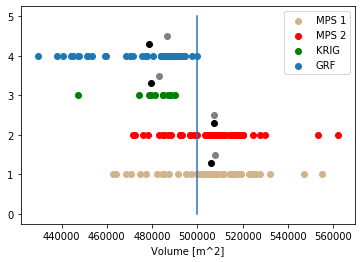

In [105]:
plt.scatter(vol_MPS1,np.ones(len(vol_MPS1)),color='tan')
plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1,color='red')
#plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1)
plt.scatter(vol_KRIG,np.ones(len(vol_KRIG))+2,color='green')
plt.scatter(vol_GRF,np.ones(len(vol_GRF))+3)
#plt.plot([real_vol, real_vol],[0,5],color = 'black')
plt.legend(['MPS 1', 'MPS 2', 'KRIG', 'GRF'])

plt.scatter(np.mean(vol_MPS1),1.3,color = 'black')
plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
#plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
plt.scatter(np.mean(vol_KRIG),3.3,color = 'black')
plt.scatter(np.mean(vol_GRF),4.3,color = 'black')

#plt.text(np.mean(vol_MPS1)+30000,1.3,'Mean')
#plt.text(np.mean(vol_MPS2)+30000,2.3,'Mean')
#plt.text(np.mean(vol_KRIG)+30000,3.3,'Mean')
#plt.text(np.mean(vol_GRF)+30000,4.3,'Mean')

plt.scatter(np.median(vol_MPS1),1.5,color = 'grey')
plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
#plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
plt.scatter(np.median(vol_KRIG),3.5,color = 'grey')
plt.scatter(np.median(vol_GRF),4.5,color = 'grey')

#plt.text(np.median(vol_MPS1)+30000,1.5,'Median')
#plt.text(np.median(vol_MPS2)+30000,2.5,'Median')
#plt.text(np.median(vol_KRIG)+30000,3.5,'Median')
#plt.text(np.median(vol_GRF)+30000,4.5,'Median')

ax = plt.gca()

#labels = [item.get_text() for item in ax.get_yticklabels()]
#labels[1] = 'Testing'
#ax.set_yticklabels(['','','MPS1','MPS2','KRIG','GRF'])

plt.plot([results_frame['Real Volume'][0]]*6, np.arange(0,6,1))
plt.xlabel('Volume [m^2]')